# IGT Reservoir with Downscaling

In [797]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
import struct
from array import array
from os.path  import join
import time

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [798]:
THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
VOLTAGE = 2.5
CURVATURE = 1

IMAGE_THRESHOLD = 1

TIME_RESOLUTION = 0.2
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

# TIME_RESOLUTION = 0.2
# K = 400
# BETA = 0.65
# TAU = 3.00

NEURON_COUNT = 200

TRAIN_BATCH_SIZE = 6000
TEST_BATCH_SIZE = 1000
FLUSH_TIME=56

MAX_ITERATION = 20
LEARNING_RATE = 2

In [799]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [800]:
input_path = 'MNIST'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [801]:
def image_to_pulses(img, threshold=IMAGE_THRESHOLD, interval=2):
    pulse_train = img.flatten()

    pulse_train = (pulse_train > threshold).astype(np.uint8)

    pulse_train = pulse_train.reshape((img.shape[0], img.shape[1])).flatten()

    zeros = np.zeros(interval * len(pulse_train), dtype=np.uint8)
    zeros[::interval] = pulse_train
    pulse_train = zeros

    pulse_train = pulse_train.reshape((7*img.shape[0], len(pulse_train)//(7*img.shape[0])))

    return pulse_train

def get_images_batch(batch_size = 600, x=x_train, y=y_train):
    random_idx = rng.choice(len(x), size=batch_size, replace=False)

    x_batch = x[random_idx]
    y_batch = np.eye(10)[y[random_idx]]

    return x_batch, y_batch

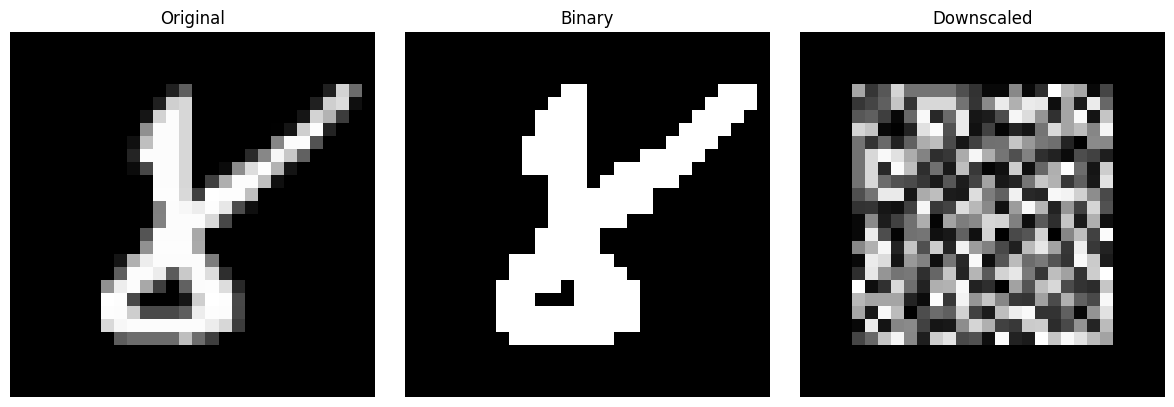

In [802]:
idx = np.random.randint(0, 60000)
img = x_train[idx]

# Cria uma figura com 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1ª Imagem: Original
axes[0].imshow(img, cmap="binary_r")
axes[0].set_title("Original")
axes[0].axis("off")  # Opcional: remove as bordas com números dos eixos

# 3ª Imagem: Método Novo
axes[1].imshow(image_to_pulses(img,interval=1).reshape((28,28)), cmap="binary_r")
axes[1].set_title("Binary")
axes[1].axis("off")

# 3ª Imagem: Método Novo
axes[2].imshow(img @ img.T, cmap="binary_r")
axes[2].set_title("Downscaled")
axes[2].axis("off")

# Ajusta o espaçamento para não cortar os títulos e exibe
plt.tight_layout()
plt.show()

In [803]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

def evolve_IGT(k, v, In_1, beta, tau, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    current_in_infinity = (k * (1 - np.exp(-((v - threshold_voltage) / scale_voltage) ** curvature)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def plot_out_current(pulse_train, out_current, title, ranges):
    time = np.arange(len(out_current)) * TIME_RESOLUTION

    _, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(6, 4),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # Pulse train
    ax1.step(time, pulse_train, where="post")
    ax1.set_ylabel("Pulse")
    ax1.set_title(title)
    ax1.grid(True)

    # Out Current
    ax2.plot(time, out_current)
    ax2.scatter(time, out_current, facecolors="none", edgecolors="tab:blue")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel(r"$I_{DS}\ (nA)$")
    ax2.grid(True)
    if ranges != ((0,0),(0,0)):
        ax2.set_xlim(ranges[0])
        ax2.set_ylim(ranges[1])

    plt.tight_layout()
    plt.show()

def generate_out_current(pulse_train, k, beta, tau, plot=False, title="", ranges=((0,0),(0,0))):
    
    out_current = np.zeros_like(pulse_train)

    for i in range(1, len(out_current)):
        out_current[i] = evolve_IGT(k, pulse_train[i], out_current[i-1], beta, tau)

    if plot:
        plot_out_current(pulse_train, out_current, title, ranges)


    return out_current

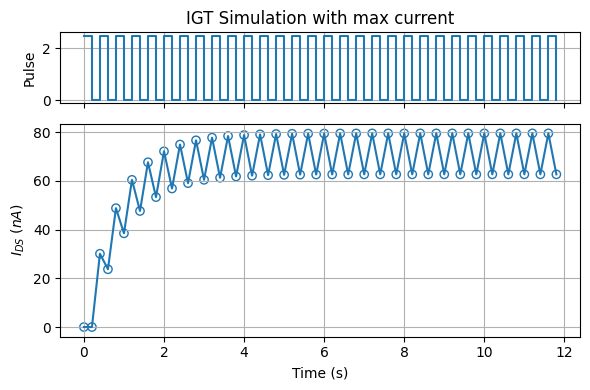

In [804]:
max_pulse = create_pulse_train(0, VOLTAGE, 1, 1, 30)

max_current = np.max(generate_out_current(max_pulse, K, BETA, TAU, True, "IGT Simulation with max current"))

In [805]:
def run_reservoir(images, tranpose=False):
    reconstructed_images_reservoir = []
    reconstructed_images = []

    for i, img in enumerate(images):
        if tranpose:
            img_pulses = image_to_pulses(img.T)
        else:
            img_pulses = image_to_pulses(img)

        new_img = []
        
        for pulse in img_pulses:
            out_current = generate_out_current(pulse, K, BETA, TAU)
            new_img.append(out_current[-1] / max_current * 255)

        new_img = np.array(new_img)
        downscaled_img = (np.array(images[i]) > IMAGE_THRESHOLD).astype(np.uint8)[::2, ::4].flatten()

        reconstructed_images_reservoir.append(new_img)
        reconstructed_images.append(downscaled_img)
    
    return reconstructed_images_reservoir, reconstructed_images

In [806]:
images, labels = get_images_batch(10)

reconstructed_images_reservoir, reconstructed_images = run_reservoir(images)

reconstructed_images_reservoir_T, reconstructed_images_T = run_reservoir(images, tranpose=True)

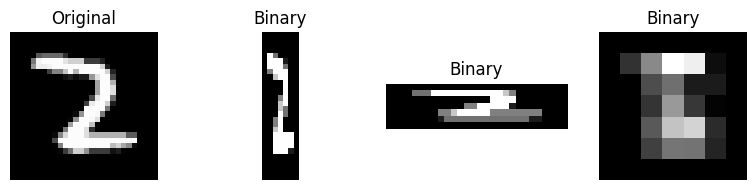

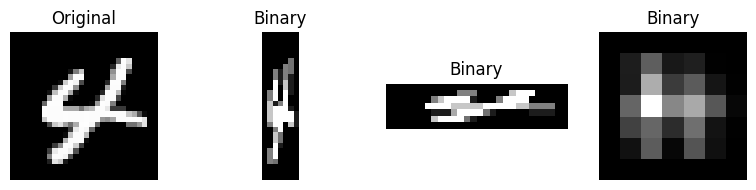

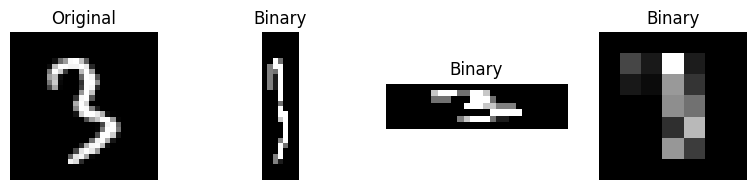

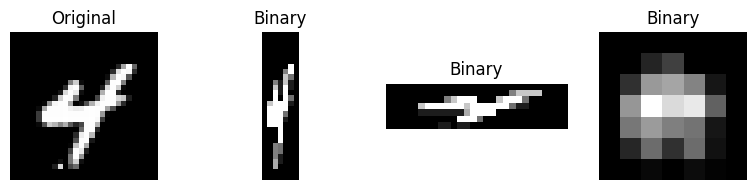

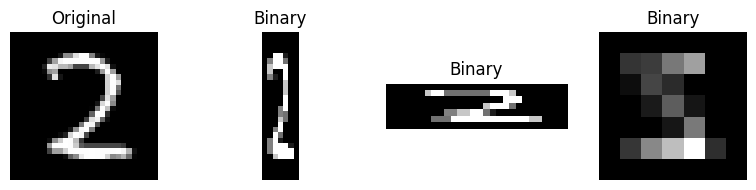

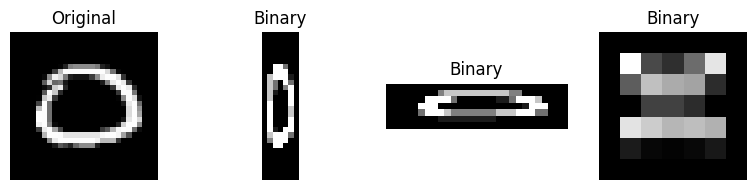

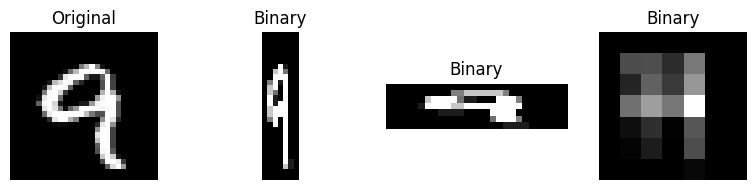

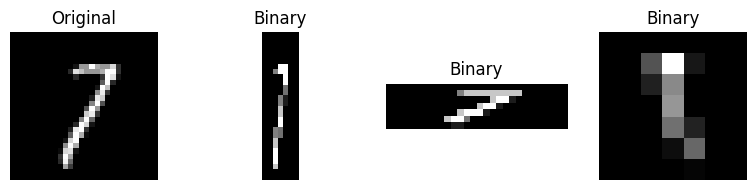

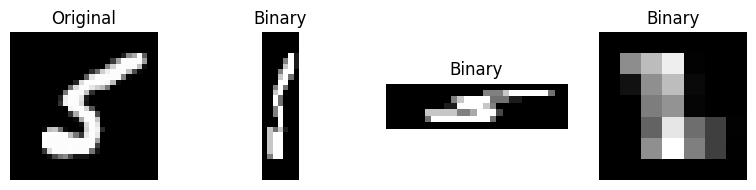

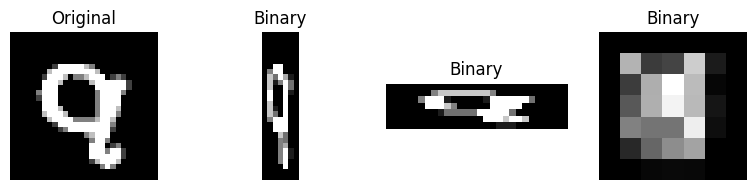

In [807]:
for i in range(len(images[:10])):
    # Cria uma figura com 1 linha e 3 colunas
    fig, axes = plt.subplots(1, 4, figsize=(8, 2))

    # 1ª Imagem: Original
    axes[0].imshow(images[i], cmap="binary_r")
    axes[0].set_title("Original")
    axes[0].axis("off")  # Opcional: remove as bordas com números dos eixos

    # 3ª Imagem: Método Novo
    axes[1].imshow(reconstructed_images_reservoir[i].reshape((28,7)), cmap="binary_r")
    axes[1].set_title("Binary")
    axes[1].axis("off")

    # 3ª Imagem: Método Novo
    axes[2].imshow(reconstructed_images_reservoir_T[i].reshape((28,7)).T, cmap="binary_r")
    axes[2].set_title("Binary")
    axes[2].axis("off")

    # 3ª Imagem: Método Novo
    axes[3].imshow(reconstructed_images_reservoir_T[i].reshape((28,7)).T @ reconstructed_images_reservoir[i].reshape((28,7)), cmap="binary_r")
    axes[3].set_title("Binary")
    axes[3].axis("off")

    # Ajusta o espaçamento para não cortar os títulos e exibe
    plt.tight_layout()
    plt.show()

In [808]:
def IGT_exponent_v(v, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.exp(-(np.maximum(0,(np.absolute(v) - threshold_voltage)) / scale_voltage) ** curvature)

def evolve_IGT_v(k, v, In_1, beta, tau):
    one_vector = np.ones_like(In_1)
    current_in_infinity = (k * (one_vector - IGT_exponent_v(v)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

def current_to_voltage_v(current_in_infinity, k, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.power(np.log(1/np.maximum(1e-9,(1-(current_in_infinity/k)))), 1/curvature) * scale_voltage + threshold_voltage

In [809]:
def run_reservoir_v(
        images,
        labels,
        normalized_reservoir,
        reservoir_state,
        weight_input,
        weight_output,
        bias_output = np.array([]),
        mode = "TRAIN",
        image_threshold=IMAGE_THRESHOLD,
        neuron_count=NEURON_COUNT
    ):

    # G = nx.from_numpy_array(np.abs(weight_reservoir), create_using=nx.DiGraph)
    # pos = nx.spring_layout(G, seed=42)

    # fig, ax = plt.subplots(figsize=(6, 6))

    states = []
    predicted_results = []

    confusion_matrix = np.zeros((labels.shape[1], labels.shape[1]))
    correct_predictions_count = 0

    current_state = reservoir_state.copy()

    for i, k in enumerate(images):
        image = image_to_pulses(k, image_threshold).reshape((14, 28))

        for data in image:
            data = data.reshape(28, 1)

            result_current = normalized_reservoir @ current_state

            current_state = evolve_IGT_v(
                K, 
                current_to_voltage_v(result_current, K) + (weight_input @ data), 
                current_state, 
                BETA, 
                TAU
            )

            # ax.clear()
            # node_colors = current_state.flatten()
            # nx.draw(
            #     G, pos, ax=ax,
            #     node_color=node_colors, cmap=plt.cm.viridis,
            #     with_labels=False, node_size=200, arrows=False
            # )
            # clear_output(wait=True)
            # display(fig)
        
        # for _ in range(FINAL_COLS):
        #     result_current = normalized_reservoir @ current_state

        #     current_state = evolve_IGT_v(
        #         K, 
        #         current_to_voltage_v(result_current, K) + (weight_input @ zeros_flush), 
        #         current_state, 
        #         BETA, 
        #         TAU
        #     )

        # print(f"add {current_state.flatten()} nos {states}")
        states.append(current_state.flatten())
        predicted_results.append(labels[i])
        
        if mode == "TEST":
            y = (weight_output @ current_state) + bias_output.reshape(-1, 1)

            predicted_label = np.argmax(y)
            expected_label = np.argmax(labels[i])

            confusion_matrix[expected_label][predicted_label] += 1

            correct_predictions_count += (expected_label == predicted_label)

        # for _ in range(FLUSH_TIME):
        #     result_current = normalized_reservoir @ current_state

        #     current_state = evolve_IGT_v(
        #         K, 
        #         current_to_voltage_v(result_current, K) + (weight_input @ zeros_flush), 
        #         current_state, 
        #         BETA, 
        #         TAU
        #     )
        
        # print(np.average(current_state))

        current_state = np.zeros((neuron_count, 1))

    states = np.array(states)
    predicted_results = np.array(predicted_results)

    if mode == "TRAIN":
        ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
        ridge.fit(states, predicted_results)

        weight_output = ridge.coef_
        bias_output = ridge.intercept_

        return weight_output, bias_output, current_state
    
    if mode == "TEST":
        confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)

        return correct_predictions_count, confusion_matrix

In [810]:
zeros_flush = np.zeros((28, 1))

time_space = np.linspace(0, zeros_flush.shape[0]* TIME_RESOLUTION, zeros_flush.shape[0])

# Input weights
weight_input = rng.normal(0, 1, size=(NEURON_COUNT, 28))

# Neurons' states
current_state = np.zeros((NEURON_COUNT, 1))

# Intern weights
weight_reservoir = rng.normal(0, 1, size=(NEURON_COUNT, NEURON_COUNT))

# Readout weights
weight_output = rng.normal(0, 1, size=(10, NEURON_COUNT))

sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
sum_matrix = (lambda x: 1/x)(sum_matrix)
normalized_reservoir = sum_matrix*weight_reservoir

true_results = []
states = []

In [811]:
def resize_images(images):
    reconstructed_images, _ = run_reservoir(images)

    reconstructed_images = (np.array(reconstructed_images)[:,:]).reshape((len(images),28,7))

    return reconstructed_images

In [812]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE)
rec_images = resize_images(images).reshape((len(images),28,7))

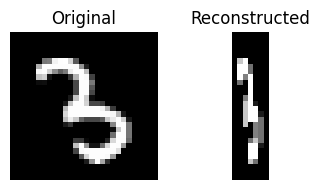

In [813]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(images[0].reshape((28,28)), cmap="binary_r")
axes[0].set_title("Original")
axes[0].axis("off")  # Opcional: remove as bordas com números dos eixos

# 3ª Imagem: Método Novo
axes[1].imshow(rec_images[0].reshape((28,7)), cmap="binary_r")
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [814]:
time_to_train = time.time()

weight_output, bias_output, current_state = run_reservoir_v(rec_images, labels, normalized_reservoir, current_state, weight_input, weight_output)

time_to_train = time.time() - time_to_train

-------------------------
VARIABLES:

Beta = 0.56
Tau = 2.6
K = 700

Neuron count = 200

Train batch size = 6000
Test batch size = 1000

Image threshold = 1

Time to train = 7.53s

-------------------------
ACCURACY:

770 / 1000 : 77.00 %


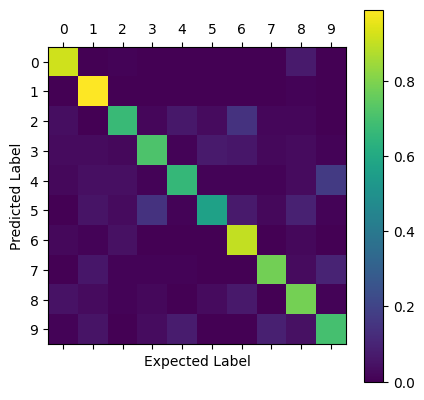

In [815]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, x_test, y_test)

images_test = resize_images(images_test).reshape((len(images_test),28,7))

correct_predictions_count, confusion_matrix = run_reservoir_v(images_test, labels_test, normalized_reservoir, current_state, weight_input, weight_output, bias_output, mode="TEST")

print(f"""-------------------------
VARIABLES:
      
Beta = {BETA}
Tau = {TAU}
K = {K}

Neuron count = {NEURON_COUNT}

Train batch size = {TRAIN_BATCH_SIZE}
Test batch size = {TEST_BATCH_SIZE}

Image threshold = {IMAGE_THRESHOLD}

Time to train = {time_to_train:.2f}s

-------------------------
ACCURACY:
""")
print(f"{correct_predictions_count} / {len(labels_test)} : {100*(correct_predictions_count/len(labels_test)):.2f} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xlabel("Expected Label")
plt.ylabel("Predicted Label")
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()

min: 0.0 max: 57.68225975534032 média: 10.707236767391308


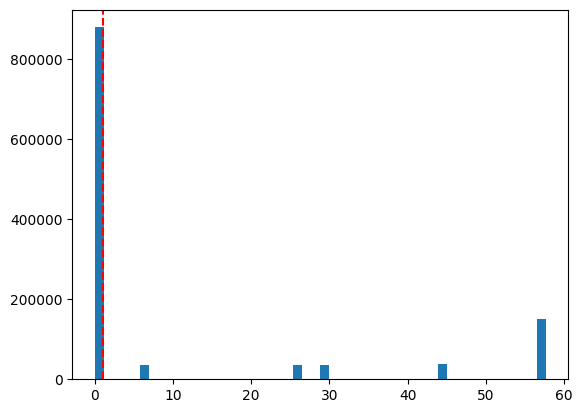

In [816]:
todos_valores = np.concatenate([img.flatten() for img in rec_images])
print("min:", todos_valores.min(), "max:", todos_valores.max(), "média:", todos_valores.mean())
plt.hist(todos_valores, bins=50)
plt.axvline(IMAGE_THRESHOLD, color='red', linestyle='--')
plt.show()